# FRAUD DETECTION 

A classic problem in financial environments. We will take a look at classifying transitions into fraud and not fraud using scikit-learn package.

This notebook will be using a synthetic database found on kaggle for educational purposes because we all need practice :-).   
The data can be found here: https://www.kaggle.com/datasets/jayjoshi37/digital-payment-fraud-detection/data

I will break this proces down into the follwoing steps:

1. Data Exploration 
2. Data prepartion and pre-processing (including feature engineering)
3. Modelling 
4. Evaluation and testing 

We have the following fields within our dataset: 

transaction_id - identifier to each transaction.   
user_id - identifier for each user.   
transaction_amount - amount for each transaction.   
transaction_type - how funds were exchanged e.g "payment" or "bank transfer".   
payment_mode - wallet, card, UPI etc.   
device_type - device transaction was made from e.g iOS.   
device_location - location of the device used to make transaction.   
account_age_days - age of the account.     
transaction_hour - time of transaction in 24 hour notation.    
previous_failed_attempts - if there were previous attempts to make fraudulent transactions.   
avg_transaction_amount - avg amount each account usually makes.   
is_international - is the trasnaction international.    
ip_risk_score - a numerical value  that quantifies the likelihood an IP address is involved in malicious activity, such as fraud, spam, or cyberattacks. 
login_attempts_last_24h - number of login attempts to the account in the last 24 hours.   
fraud_label- is the transaction fraud or not.


## Data Exploration 

In [388]:
# First we need to start by acquiring all of our dependecies 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [389]:
#Now we will load our data into our notebook for modelling:
current_dir = Path.cwd()
print(current_dir)              #this directory is 1 level too low in the project structure
parent_dir = current_dir.parent #go up 1 level in the structure 
print(parent_dir)               #now we are in the parent directory that we can now use to naviagte into the dataset 
file_path = parent_dir/ "dataset" / "Digital_Payment_Fraud_Detection_Dataset.csv" 
print(file_path)                #now we are in the correct bracnh of the tree where our dataset is

fraud = pd.read_csv(file_path)  #IT WORKED!!!


/Users/leta/Desktop/Data Science Career/Python/Python Projects/FraudDetection/modelling
/Users/leta/Desktop/Data Science Career/Python/Python Projects/FraudDetection
/Users/leta/Desktop/Data Science Career/Python/Python Projects/FraudDetection/dataset/Digital_Payment_Fraud_Detection_Dataset.csv


In [390]:
fraud.shape #dimensions of the dataframe

(7500, 15)

In [391]:
#Let us take a look into the data we have 
fraud.head()

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0
3,T4,U8850,29952.99,Payment,Wallet,iOS,Chennai,800,1,3,18095.89,0,0.797,2,0
4,T5,U9049,7843.13,Payment,UPI,Web,Delhi,301,4,1,9317.49,1,0.468,1,0


In [392]:
#In this dataset we have mostly numerical variables with a few catgeroical variables.
#Let us look at what fields we have
fraud.keys() #column names of us data


Index(['transaction_id', 'user_id', 'transaction_amount', 'transaction_type',
       'payment_mode', 'device_type', 'device_location', 'account_age_days',
       'transaction_hour', 'previous_failed_attempts',
       'avg_transaction_amount', 'is_international', 'ip_risk_score',
       'login_attempts_last_24h', 'fraud_label'],
      dtype='str')

In [393]:
#What unique labels do we have in the dataset 
fraud.nunique()
# The fields with the highest unique values are the ID fields, transaction amounts, account ages, avgerage transaction amounts, ip risk scores 
# ID fields are just unqiue ientifiers but have no bearing on prediction therefore we will drop these fields especially since they have many unique values.  
# We will plore some more of these fields to see there bearing on the predcitve power of our models using exploratory data analysis and data mining.

transaction_id              7500
user_id                     5106
transaction_amount          7499
transaction_type               3
payment_mode                   4
device_type                    3
device_location                5
account_age_days            1943
transaction_hour              24
previous_failed_attempts       5
avg_transaction_amount      7498
is_international               2
ip_risk_score               1000
login_attempts_last_24h        9
fraud_label                    2
dtype: int64

In [394]:
# Finally let us see of the data is balanced or not 
fraud["fraud_label"].value_counts(normalize=True) #count all fraud labels and get proportion

# Fraud - 6.52% of observations    
#Non fraud - 93.28% of observations 

# Our data is very skewed towards non fraud transactions.
# This will infrom our metric to measure perfomrance (probably balanced accuarcy, recall and precision) 
# as well as how we stratify the data when partitioning into test and train sets. 


fraud_label
0    0.9348
1    0.0652
Name: proportion, dtype: float64

Our variables with categorical information being: transaction_type, payment_mode, device_type and device_location do not have too many unqiue values.  
This infroms what methods we can use to deal with these values for classification models that only use numerical data.  
- A possible solution would be to use dummy variables. 

##  DATA PREPARATION AND PRE-PROCESSING 


In [395]:
# As we have seen above the ID variables have no bearing on the prediction so we will remove them.
fraud = fraud.drop(columns= ["transaction_id", "user_id", "transaction_type", "payment_mode", "device_type"]) #removing ID columns
fraud.keys()

Index(['transaction_amount', 'device_location', 'account_age_days',
       'transaction_hour', 'previous_failed_attempts',
       'avg_transaction_amount', 'is_international', 'ip_risk_score',
       'login_attempts_last_24h', 'fraud_label'],
      dtype='str')

FEATURE ENGINEERING 
We will now create features that improve the performance of our models based on the EDA we conducted and the insights we gathered. 

In [443]:
# Now we will take partition the data into dependent and indepenedt variables. 
x =fraud[['transaction_amount', 'device_location', 'account_age_days',
       'transaction_hour', 'previous_failed_attempts',
       'avg_transaction_amount', 'is_international', 'ip_risk_score',
       'login_attempts_last_24h']]
y = fraud[['fraud_label']]                               #subsetting our predicted variable 

In [444]:
# Partitioning our data 
# The data will be partitioned into tran and test splits at a 70/30% proportion 

from sklearn.model_selection import train_test_split #package to spilt our data 

x_train, x_test, y_train, y_test = train_test_split(x,y,              #our dependent and independent variables to be used
                                                    stratify = y,     #keeping proportion of fraud and not fraud equal in the the train and test sets
                                                    random_state=123, #setting a seed for reproducibility 
                                                    test_size=0.3)    #30% test size


In [445]:
x_train.keys()

Index(['transaction_amount', 'device_location', 'account_age_days',
       'transaction_hour', 'previous_failed_attempts',
       'avg_transaction_amount', 'is_international', 'ip_risk_score',
       'login_attempts_last_24h'],
      dtype='str')

In [446]:
y_train.keys()

Index(['fraud_label'], dtype='str')

## MODELLING 

In [447]:
# Now we can start modelling our data using sklearn.
#First we download dependencies
from sklearn.linear_model import LogisticRegression #this model acts as our basline model for binary classification 
from sklearn.pipeline import Pipeline #creating a data pre-propcessing pipeline for our test set 
from sklearn.preprocessing import FunctionTransformer #to create feature engineering functions 

In [471]:
def new_features(test_data):

    df = test_data.copy()

    #creating the location buckets 
    fraud_location = {  
    "Mumbai":5,
    "Hyderabad" :5,
    "Chennai" : 2,
    "Bangalore" : 2,
    "Delhi" : 1}
    df["fraud_bucket_location"] = df["device_location"].map(fraud_location)

    ip_risk = []
    login_number = []
    account_age = []

    #creating our risk buckets 
    df["ip_risk_bucket"] = np.where((df['ip_risk_score'] < 0.51) | 
                                    (df['ip_risk_score'] > 0.86), 2, 0)

    #creating the number of login attempt buckets 
    df["account_age_bucket"] = np.where((df['account_age_days'] >= 1190 ) &
                                         (df['account_age_days'] <= 1855), 5,0)

  

    return df

In [472]:
#scaling and get dummies (one hot encoding our variables)
numeric_features = ['transaction_amount', 'account_age_days',
                     'transaction_hour','avg_transaction_amount', 'ip_risk_score'] 
    
categorical_features = ['device_location', 'previous_failed_attempts',  'is_international', 'login_attempts_last_24h']

In [473]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformation = StandardScaler()
categorical_transformation = OneHotEncoder()

preprocess_data = ColumnTransformer(
    transformers= ([
        ("num" , numeric_transformation, numeric_features),
        ("cat", categorical_transformation,categorical_features)
    ]))

In [490]:
featuretransformer = FunctionTransformer(new_features)

pipeline = Pipeline([
    ("feature_engineering", featuretransformer),
    ("preprocess", preprocess_data),
    ("Logistic_regression", LogisticRegression())
])

In [491]:
#We will now us the pipleine on our test data 
pipeline.fit(x_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function new...t 0x12498e980>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword a

## EVALUATION AND TESTING 
We have trained our model on the train set.   
We can now use the metrics mentined earlier like balanced accuracy, precision and recall to judge our models

**Precision** - of all the positievs identified how many were truly positive?  
**Recall**- of all possible positive instances, how many did the model catch? 

For fraud detection, we value recall as our main metric.   
This is beacuse catching every fraudlent trasaction allows for the least damage to our client base as opposed to flagging a genuine transaction as fraud that can be reversed wuth no harm to the user. 

In [492]:
y_pred_log = pipeline.predict(x_test) #making predictios on the train data 


In [493]:
# Importing balanced accuracy
from sklearn.metrics import accuracy_score,balanced_accuracy_score, precision_recall_curve, confusion_matrix,precision_score, recall_score, ConfusionMatrixDisplay #importing all necesarry metrics

In [494]:
accuracy_score(y_test, y_pred_log) #we have a very high accuracy score of 0.935


0.9346666666666666

In [495]:
balanced_accuracy_score(y_test,y_pred_log) #our balaned accuracy score is very lowe at 0.5

0.5

In [496]:
precision_score(y_test,y_pred_log) # precision is 0%

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


0.0

In [497]:
recall_score(y_test,y_pred_log) #recall is 0%

0.0

This indicates that the imbalance in the dataset even after stratifying the data.     
This indicates that our model learned to predict non fraud every time (class 0) to get a high accuracy bot lowe balanced accuracy, precision and recall   
Therefore we need to find another way to ensure we can identify all the positive cases. 
# We can award a greater penalty to predicting a very imbalanced outcome 

In [498]:
featuretransformer2 = FunctionTransformer(new_features)

pipeline2 = Pipeline([
    ("feature_engineering", featuretransformer),
    ("preprocess", preprocess_data),
    ("Logistic_regression", LogisticRegression(class_weight= "balanced"))
]) #adding penatly to predciting only one class accuractely 


In [499]:
pipeline2.fit(x_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function new...t 0x12498e980>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword a

In [500]:
y_pred2_log = pipeline2.predict(x_test) 

In [ ]:
balanced_accuracy_score(y_test, y_pred2_log) #Our model still does not have the best balanced accuracy at 52.0%

0.5195590361679622

In [ ]:
precision_score(y_test, y_pred2_log) # precision is also very low 7.03%

0.07030527289546716

In [ ]:
recall_score(y_test, y_pred2_log) #however, our recall is much higher therefore, we have caught more our our fraud cases 51.7%

0.5170068027210885

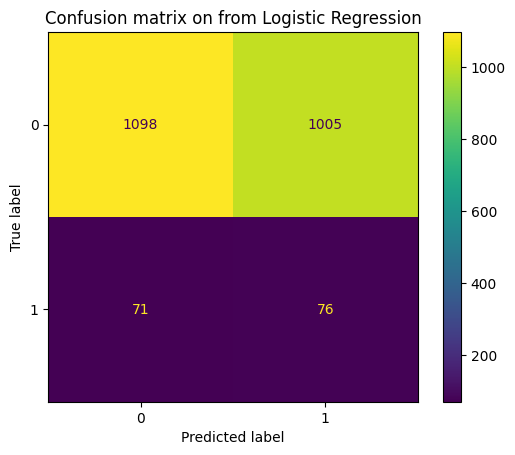

In [ ]:
confusion_matrix_log = ConfusionMatrixDisplay.from_predictions( #creating confusion matrix diagram from predictions
    y_test,                                                     #comparing y test data to our predcited values from the logistic regression model
    y_pred2_log
)

plt.title("Confusion matrix on from Logistic Regression")  #setting up the lablels 
plt.show()

In conculsion - even after we add extra penalty to predict each class as good as possible. 
We will now try to use another classification model 

In [506]:
# Now we will try to use a Random Forest Model 
from sklearn.ensemble import GradientBoostingClassifier #using a Random Forest model

In [539]:
featuretransformer3 = FunctionTransformer(new_features)

pipeline3 = Pipeline([
    ("feature_engineering", featuretransformer),
    ("preprocess", preprocess_data),
    ("Logistic_regression", GradientBoostingClassifier(n_estimators= 500,
                                                       loss="exponential"))
])  #having the penalty between classes being equal

In [540]:
pipeline3.fit(x_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function new...t 0x12498e980>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword a

In [541]:
y_pred_gradient_boost = pipeline3.predict(x_test)

In [542]:
balanced_accuracy_score(y_test, y_pred_gradient_boost) #is lower than our logistic regression with classes weighed equally 

0.4997622444127437

In [543]:
precision_score(y_test, y_pred_gradient_boost) #also very low 0

0.0

In [544]:
recall_score(y_test, y_pred_gradient_boost) #low like our logistic regression at 0

0.0

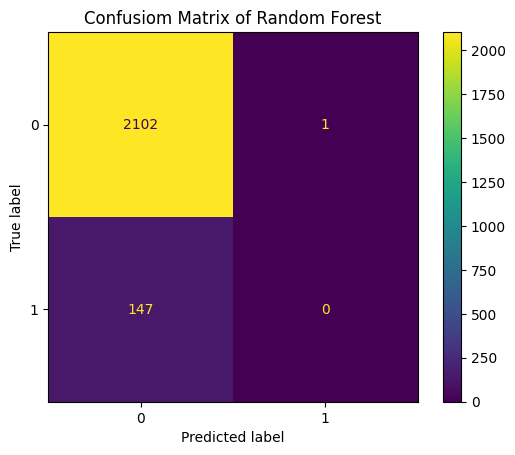

In [545]:
confusion_matrix_rando = ConfusionMatrixDisplay.from_predictions(
    y_test,                #comparing y test data to our predcited values from the random forest model
    y_pred_gradient_boost
)
plt.title("Confusiom Matrix of Random Forest")
plt.show()

Both our models minimise error by just predicting not fraud for all the transaction since the data is so skewed in not fraud approximatley 94/6 %.
Therefore since we have such unbalanced data we have to give a much larger penatly to make our models predict both classes more accuractely.   

## MODEL WITH GREATER PENALTY 

In [561]:
# We will now create both models with a greater penatly for predicting wrong in our fraud class as well as lower our acceptance threshold for fraud.
featuretransformer4 = FunctionTransformer(new_features)

pipeline4 = Pipeline([
    ("feature_engineering", featuretransformer),
    ("preprocess", preprocess_data),
    ("Logistic_regression", LogisticRegression(class_weight= {0:1, 1:10}))
])

featuretransformer4 = FunctionTransformer(new_features)

pipeline5 = Pipeline([
    ("feature_engineering", featuretransformer),
    ("preprocess", preprocess_data),
    ("Logistic_regression", RandomForestClassifier(class_weight= {0:1, 1:10}))
])

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


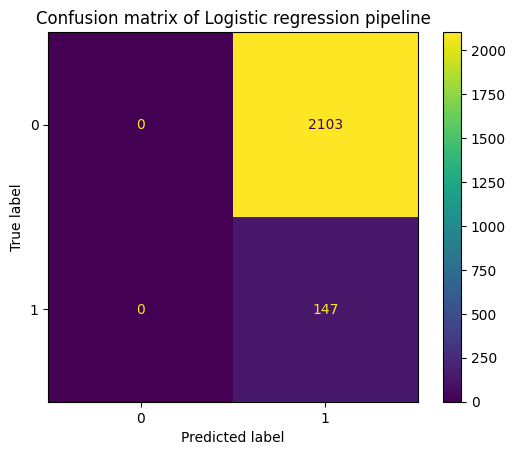

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


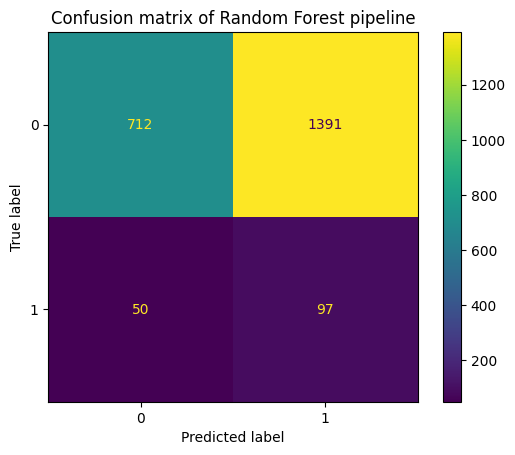

In [573]:
algos = [pipeline4, pipeline5] #list of our pipelines on training data 
pipeline_names = ["Logistic regression pipeline" , "Random Forest pipeline"]
b_accuracy =[]        #empty list of balanced accuracy scores 
recall_metric = []    #empty list of recall  scores  
precision_metric = [] #empty list of precision  scores
threshold = 0.05

for a, p  in zip(algos, pipeline_names):  #loop that fits both models and appends balanced accuracy, precsion and recall to the empty lists 
    a.fit(x_train, y_train)
    predictions = (a.predict_proba(x_test)[:,1] >= threshold).astype(int)
    acc = balanced_accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions)
    rec = recall_score(y_test, predictions)
    
    b_accuracy.append(acc)
    recall_metric.append(rec)
    precision_metric.append(prec)

    
    confusion_matrix = ConfusionMatrixDisplay.from_predictions(
                y_test,                #comparing y test data to our predcited values from the random forest model
                predictions
            )
    plt.title(f"Confusion matrix of {p}")
    plt.show()


In [574]:
main_metrics =pd.DataFrame()                                                #create an empty dataframe to add metrics to 
main_metrics["Description"] = [ "Balanced accuracy", "Recall", "Precision"] #create columns of metrc names  
main_metrics["Logistic Regression"] = [b_accuracy[0], recall_metric[0], precision_metric[0]] #add metrics for Logistic regression model
main_metrics["Random Forest"] = [b_accuracy[1], recall_metric[1], precision_metric[1]]       #add metrics for Random forest 


main_metrics

,Description,Logistic Regression,Random Forest
0,Balanced accuracy,0.500000,0.499214
1,Recall,1.000000,0.659864
2,Precision,0.065333,0.065188


Okay, there are many takeaways from this experiment:   

1) Our Logistic regression model is very aggressive. It is able to catch all of the fraud cases at 100% recall (which is great) but it does so by guessing everything as fraud. 
- This means that every custimer would have every transactions falgged as fraud if this model was implemented which is a horrendous user expirience. 
- As a result the balanced accuracy falls since we got 100% of 50% and 0% of 50% of predcitions correct. 

2) Our Random Forest is much better with a recall at 66.0% so it catches the majority of fraud. 
-  However we still have many majority of non fraud cases being calssified as fraud so it will still be very inconveneint for all of our users.   

**All 3 models perform relatively poorly in atleast 2 metrics that are the most important.**. 

Therefore we can use resampling techniques to solve this issue.   
For severly unbalanced data, there is a resampling technique called SMOTE resampling. 

### SMOTE 
Synthetic Minority Over-Sampling Technique (SMOTE)

SMOTE is a data-level resampling technique that generates synthetic (artificial) samples for the minority class.   
Instead of simply duplicating existing examples, it creates new data points by interpolating between existing ones.   
This approach allows the model to learn broader patterns and reduces the risk of overfitting to repeated samples

In [575]:
#First let us start by importing the necessary library 
from imblearn.over_sampling import SMOTE 

In [ ]:
# Now we will resample our data 
# This will involve adding the resampling step midway through into our pipeline 
smote = SMOTE(sampling_strategy="minority", random_state= 40)
x_train_s, y_train_s =  smote.fit_resample(x_train, y_train)

ValueError: could not convert string to float: 'Bangalore'

In [ ]:
counts = y_train_s.value_counts() #getting the count of our resampled fraud and non fraud data  points


plt.bar(range(len(counts)),counts.values, color = ['blue','red']) #plotting our resampled data on a bar graph 
plt.xticks([0,1],['Non-fraud','Fraud'])
plt.show()

### Now we will re-run our models on the resampled data

In [ ]:
log_resample = LogisticRegression()
random_resample = RandomForestClassifier()

algos_resample = [log_resample, random_resample] #list of our algorithm on training data 
b_accuracy_resample =[]        #empty list of balanced accuracy scores 
recall_metric_resample = []    #empty list of recall  scores  
precision_metric_resample = [] #empty list of precision  scores

for a in algos_resample:  #loop that fits both models and appends balanced accuracy, precsion and recall to the empty lists 
    a.fit(x_train_s, y_train_s)
    predictions = a.predict(x_test)
    acc = balanced_accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions)
    rec = recall_score(y_test, predictions)
    
    b_accuracy_resample.append(acc)
    recall_metric_resample.append(rec)
    precision_metric_resample.append(prec)

In [ ]:
main_metrics_resample = pd.DataFrame()                                                #create an empty dataframe to add metrics to 
main_metrics_resample["Description"] = [ "Balanced accuracy", "Recall", "Precision"] #create columns of metrc names  
main_metrics_resample["Logistic Regression"] = [b_accuracy_resample[0], recall_metric_resample[0], precision_metric_resample[0]] #add metrics for Logistic regression model
main_metrics_resample["Random Forest"] = [b_accuracy_resample[1], recall_metric_resample[1], precision_metric_resample[1]]       #add metrics for Random forest 


main_metrics_resample